# DEF-D Fysieke Ontwerpopdracht 2 invul template

## Groep informatie

Aan het einde van deze ontwerpopdracht lever je als groep één gezamenlijk notebook in (als in *PR* op GitHub en de link op Brightspace). Zet jullie groepsnummer, studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan.

| Groep: 01     |  |
| :-------------|:-------------|
| Daan van der Molen| 6530095 |
| Abel van Oord| 6580920 |

## *Opdracht 1*: Sanity check 3

#### Voeg hier een foto van de schets van je plaatcondensator in. Geef daarbij ook duidelijk de waarde van $A$ en $d$ aan.
<img src="plaatcondensator.jpg" alt="schets student 1" width="400"/>

In [1]:
# Schrijf hier een python functie die de capaciteit van een plaatcondensator uitrekent. Zorg dat de functie
# als input de ontwerpparameters van de vlakke plaat formule accepteert (oppervlakte, afstand en diëlektrische
# constante) en als output de capaciteit van de vlakke plaat condensator met die ontwerpparameters.
# Je gaat deze formule de rest van de dag gebruiken: controleer hem goed!
epsilon_0 = 8.854e-12

def bereken_capaciteit(A, d, epsilon_r):
    capaciteit = (epsilon_0*epsilon_r*A) / d 
    return capaciteit

# Optioneel: schrijf je functie zodanig dat je arrays als input kan geven en (dus) ook arrays als output.

In [2]:
# Gebruik je formule om uit te rekenen wat je verwacht dat de capaciteit van jullie vlakke plaat condensatoren
# gaat zijn.

C = (bereken_capaciteit(0.01, 0.002, 2.6))*(10**12) # F


print(f"Berekende capaciteit plaatcondensator groep 01 is {C:.1f} pF")

Berekende capaciteit plaatcondensator groep 01 is 115.1 pF


#### Voeg hier een foto van je plaatcondensator en van de meting op de scope in. Dus 2 foto's.
<img src="plaatcondensator (2).jpg" alt="plaatcondensator" width="400"/>
<img src="aflezeningoscilloscoop.jpg" alt="aflezingoscilloscoop" width="400"/>

### Meting capaciteit
Vul onderstaande tabel in. Bij Sanity check 2 heb je afgeleid hoe je van berekende capaciteit naar berekend voltage gaat en terug. 


| Namen         | Berekende capaciteit   | Berekend Voltage | Gemeten Voltage | Gemeten capaciteit   |
|-------------|-------------:|-------------:|-------------:|-------------:|
| groep 01| 115.1 pF |1.05 V | 1.1 V |110 pF |

## *Opdracht 2:* Synthese.

#### Voeg hier voor een foto van je schets(en) van minimaal drie sensoren in.
<img src="weegschaal.jpg" alt="weegschaal" width="400"/>
<img src="vochtigheidsmeter.jpg" alt="vochtigheidsmeter" width="400"/>
<img src="verplaatsingsmeter.jpg" alt="verplaatsingsmeter" width="400"/>


## Opdracht 3: Welke sensor gaan jullie maken?

Pas deze tekst aan: Wij gaan een sensor maken die massa meet.

## Opdracht 4: Uitgewerkte schets (afmetingen!) en plot van de ontwerpgrafiek.

#### Voeg hier een foto van jullie uitgewerkte  schets van de sensor die jullie gaan maken in
<img src="weegschaal met afmetingen.jpg" alt="weegschaal met afmetingen" width="400"/>

Text(0.5, 1.0, 'ontwerpgrafiek weegschaal')

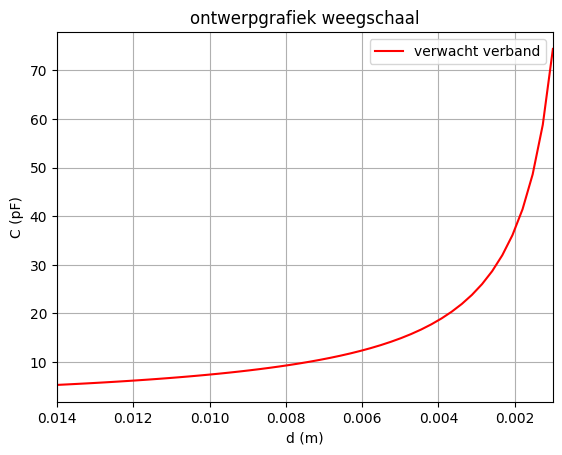

In [3]:
# Plot hier de verwachte ontwerpgrafiek van jullie sensoren.
import numpy as np
import matplotlib.pyplot as plt

d = np.linspace(0.014,0.001,50) # drukt niet compleet in door het gewicht
C = bereken_capaciteit(0.0084, d, 1)*(10**12) # 1 als epsilon_r voor lucht

plt.figure()
plt.grid()
plt.xlim(0.014,0.001)
plt.plot(d,C, 'r-', label = 'verwacht verband')
plt.xlabel('d (m)')
plt.ylabel('C (pF)')
plt.legend()
plt.title('ontwerpgrafiek weegschaal')

## Opdracht 5: Invullen tabel LTSpice.

|         | Capaciteit waarde (pF)  | LTSpice berekend output Vpp (mV)|
|-------------|-------------:|-------------:|
| minmale capaciteit| 5 |25.1 |
| gemiddelde capaciteit| 37.5 |188.4 |
| maximale capaciteit| 70 |351.5 |

## Opdracht 6: Foto's werkende opstelling.

#### Voeg hier de foto's van je sensoren in actie in.
<img src="meetopstelling.jpg" alt="meetopstelling" width="400"/>

## Opdracht 7: Plot de kalibratiegrafiek.

a = 27.9508 ± 0.4694
b =17.9885 ± 0.0941


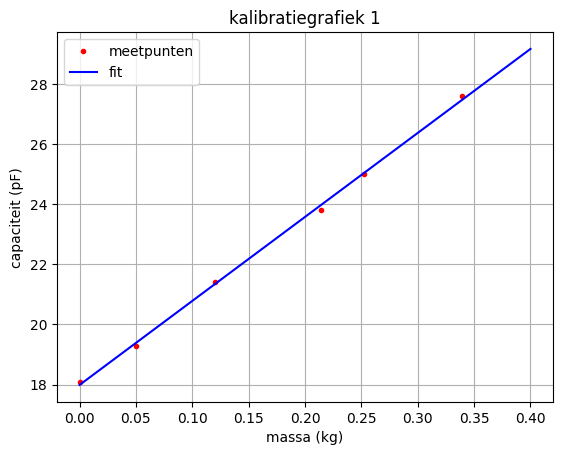

In [4]:
# Plot hier je gemeten kalibratiegrafiek en plot in dezelfde figuur ook je verwachte ontwerpgrafiek.

from scipy.optimize import curve_fit

massa = ([0, 0.2526, 0.339, 0.214, 0.120, 0.05])
capaciteit = ([18.1, 25.0, 27.6, 23.8, 21.4, 19.3])

def fit_model(x, a, b):
    return a * x + b

popt, pcov = curve_fit(fit_model, massa, capaciteit)
perr = np.sqrt(np.diag(pcov))

a, b = popt
onzekerheid_a, onzekerheid_b = perr

# Resultaten printen
print(f"a = {a:.4f} ± {onzekerheid_a:.4f}")
print(f"b ={b:.4f} ± {onzekerheid_b:.4f}")

m_fit = np.linspace(0,0.4,100)

# Plotten van de data en de fit
plt.figure()
plt.plot(massa, capaciteit, 'r.', label='meetpunten')
plt.plot(m_fit, fit_model(m_fit, *popt), 'b-', label= 'fit')
plt.xlabel('massa (kg)')
plt.ylabel('capaciteit (pF)')
plt.legend()
plt.title('kalibratiegrafiek 1')
plt.grid()
plt.show()

## Opdracht 8: Vul de tekst aan.

Onze sensor kan nog verbetered worden door de volgende verbeteringen (minimaal 2):

* schuimhoekjes vastplakken
* een vaste plek voor de massa bij elke meting

## Opdracht 9: Uiteindelijke ontwerp en kalibratiegrafiek.

#### Voeg hier een foto van je uiteindelijke sensor in.
<img src="verbeterde meetopstelling.jpg" alt="verbeterde meetopstelling" width="400"/>

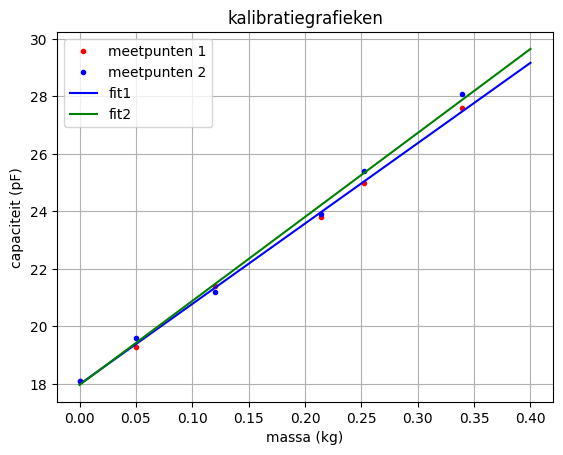

In [5]:
# Plot hier je oorspronkelijke en je uiteindelijke kalibratiegrafieken, fit daar een bijpassende lijn door
# en zet ook de verwachte ontwerpgrafiek erbij

massa2 = ([0, 0.2526, 0.339, 0.214, 0.120, 0.05])
capaciteit2 = ([18.1, 25.4, 28.1, 23.9, 21.2, 19.6])

popt2, pcov2 = curve_fit(fit_model, massa2, capaciteit2)
perr2 = np.sqrt(np.diag(pcov2))

plt.figure()
plt.plot(massa, capaciteit, 'r.', label='meetpunten 1')
plt.plot(massa2,capaciteit2,'b.', label='meetpunten 2')
plt.plot(m_fit, fit_model(m_fit, *popt), 'b-', label= 'fit1')
plt.plot(m_fit, fit_model(m_fit, *popt2), 'g-', label= 'fit2')
plt.xlabel('massa (kg)')
plt.ylabel('capaciteit (pF)')
plt.legend()
plt.title('kalibratiegrafieken')
plt.grid()
plt.show()

<img src="ontwerpgrafiek weegschaal.png" alt="ontwerpgrafiek weegschaal" width="400"/>

## Opdracht 10: Vul hieronder de conclusie in.

onze sensor is geschikt om de massa van een object te meten en doet dit met goede nauwkeurigheid. 

De iteratie heeft voor een klein verschil gezorgd maar omdat onze opstelling aanvankelijk al best goed was, is het verschil niet aanzienlijk.

we meten met onze opstelling in een lage range van pF (0-28). Je ziet alsnog dat we tot ongeveer 15 pF gelijk lopen met de ontwerpgrafiek maar dat we daarna het exponentiele verband missen, dit ligt volgens ons aan het feit dat we dus in een lage range van pF hebben gemeten.

de vlakke plaat formule klopt genoeg voor onze sensor.

## Opdracht 11: Kopieer hieronder de leerdoelen.
1. Het kunnen gebruiken van de eigenschappen van een elektrische component in een ontwerpproces om een fysische grootheid te meten.
2. Kennis hebben van gedrag van elektrische componenten en meetopstellingen.
3. Onderdelen van een datasheet zoals een kalibratiegrafiek opstellen, gevoeligheid en onzekerheid beschrijven.

kopieer hier de cel(len) waaruit blijkt dat jullie leerdoel 1 beheersen.

In [6]:
# Schrijf hier een python functie die de capaciteit van een plaatcondensator uitrekent. Zorg dat de functie
# als input de ontwerpparameters van de vlakke plaat formule accepteert (oppervlakte, afstand en diëlektrische
# constante) en als output de capaciteit van de vlakke plaat condensator met die ontwerpparameters.
# Je gaat deze formule de rest van de dag gebruiken: controleer hem goed!
epsilon_0 = 8.854e-12

def bereken_capaciteit(A, d, epsilon_r):
    capaciteit = (epsilon_0*epsilon_r*A) / d 
    return capaciteit

# Optioneel: schrijf je functie zodanig dat je arrays als input kan geven en (dus) ook arrays als output.

In [7]:
# Gebruik je formule om uit te rekenen wat je verwacht dat de capaciteit van jullie vlakke plaat condensatoren
# gaat zijn.

C = (bereken_capaciteit(0.01, 0.002, 2.6))*(10**12) # F


print(f"Berekende capaciteit plaatcondensator groep 01 is {C:.1f} pF")

Berekende capaciteit plaatcondensator groep 01 is 115.1 pF


kopieer hier de cel(len) waaruit blijkt dat jullie leerdoel 2 beheersen.

<img src="plaatcondensator (2).jpg" alt="plaatcondensator" width="400"/>
<img src="aflezeningoscilloscoop.jpg" alt="aflezingoscilloscoop" width="400"/>

<img src="verbeterde meetopstelling.jpg" alt="verbeterde meetopstelling" width="400"/>

kopieer hier de cel(len) waaruit blijkt dat jullie leerdoel 3 beheersen.

a = 27.9508 ± 0.4694
b =17.9885 ± 0.0941


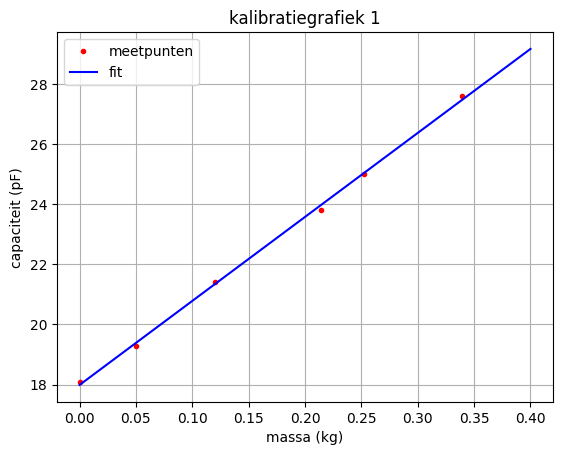

In [8]:
# Plot hier je gemeten kalibratiegrafiek en plot in dezelfde figuur ook je verwachte ontwerpgrafiek.

from scipy.optimize import curve_fit

massa = ([0, 0.2526, 0.339, 0.214, 0.120, 0.05])
capaciteit = ([18.1, 25.0, 27.6, 23.8, 21.4, 19.3])

def fit_model(x, a, b):
    return a * x + b

popt, pcov = curve_fit(fit_model, massa, capaciteit)
perr = np.sqrt(np.diag(pcov))

a, b = popt
onzekerheid_a, onzekerheid_b = perr

# Resultaten printen
print(f"a = {a:.4f} ± {onzekerheid_a:.4f}")
print(f"b ={b:.4f} ± {onzekerheid_b:.4f}")

m_fit = np.linspace(0,0.4,100)

# Plotten van de data en de fit
plt.figure()
plt.plot(massa, capaciteit, 'r.', label='meetpunten')
plt.plot(m_fit, fit_model(m_fit, *popt), 'b-', label= 'fit')
plt.xlabel('massa (kg)')
plt.ylabel('capaciteit (pF)')
plt.legend()
plt.title('kalibratiegrafiek 1')
plt.grid()
plt.show()

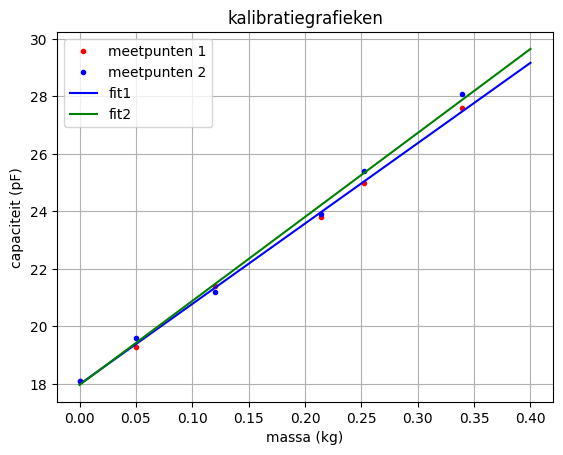

In [9]:
# Plot hier je oorspronkelijke en je uiteindelijke kalibratiegrafieken, fit daar een bijpassende lijn door
# en zet ook de verwachte ontwerpgrafiek erbij

massa2 = ([0, 0.2526, 0.339, 0.214, 0.120, 0.05])
capaciteit2 = ([18.1, 25.4, 28.1, 23.9, 21.2, 19.6])

popt2, pcov2 = curve_fit(fit_model, massa2, capaciteit2)
perr2 = np.sqrt(np.diag(pcov2))

plt.figure()
plt.plot(massa, capaciteit, 'r.', label='meetpunten 1')
plt.plot(massa2,capaciteit2,'b.', label='meetpunten 2')
plt.plot(m_fit, fit_model(m_fit, *popt), 'b-', label= 'fit1')
plt.plot(m_fit, fit_model(m_fit, *popt2), 'g-', label= 'fit2')
plt.xlabel('massa (kg)')
plt.ylabel('capaciteit (pF)')
plt.legend()
plt.title('kalibratiegrafieken')
plt.grid()
plt.show()